## Import Library

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam # Import Adam optimizer
from tensorflow.keras.applications import MobileNetV2 # Import MobileNetV2 for transfer learning
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_DIR = 'D:\kerjo\dibimbingbootcamp\day-31-DL' 

TRAIN_IMAGE_DIR = os.path.join(DATA_DIR, 'train')
TEST_IMAGE_DIR = os.path.join(DATA_DIR, 'test')
TRAINING_CSV = os.path.join(DATA_DIR, 'Training_set.csv')
TESTING_CSV = os.path.join(DATA_DIR, 'Testing_set.csv')

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2 

TUNING_EPOCHS = 5
FINAL_EPOCHS = 30

<>:1: SyntaxWarning: invalid escape sequence '\k'
<>:1: SyntaxWarning: invalid escape sequence '\k'
C:\Users\BUDI\AppData\Local\Temp\ipykernel_3196\3519592531.py:1: SyntaxWarning: invalid escape sequence '\k'
  DATA_DIR = 'D:\kerjo\dibimbingbootcamp\day-31-DL'


## Read CSV

In [3]:
try:
    train_df = pd.read_csv(TRAINING_CSV)
    test_df = pd.read_csv(TESTING_CSV)
except FileNotFoundError:
    print(f"Error: Pastikan path DATA_DIR '{DATA_DIR}' sudah benar dan file CSV ada.")
    exit()

In [4]:
train_df.head(), test_df.head()

(      filename                     label
 0  Image_1.jpg          SOUTHERN DOGFACE
 1  Image_2.jpg                    ADONIS
 2  Image_3.jpg            BROWN SIPROETA
 3  Image_4.jpg                   MONARCH
 4  Image_5.jpg  GREEN CELLED CATTLEHEART,
       filename
 0  Image_1.jpg
 1  Image_2.jpg
 2  Image_3.jpg
 3  Image_4.jpg
 4  Image_5.jpg)

## Split Dataset

In [5]:
train_data, val_data = train_test_split(train_df,
                                        test_size=VALIDATION_SPLIT,
                                        stratify=train_df['label'], 
                                        random_state=42) 

print(f"Total data pelatihan asli: {len(train_df)}")
print(f"Data pelatihan setelah split: {len(train_data)}")
print(f"Data validasi setelah split: {len(val_data)}")
print(f"Total data uji (tanpa label): {len(test_df)}")

NUM_CLASSES = train_df['label'].nunique()
CLASS_NAMES = sorted(train_df['label'].unique())
print(f"\nJumlah kelas yang terdeteksi: {NUM_CLASSES}")
print(f"Nama kelas: {CLASS_NAMES}")

Total data pelatihan asli: 6499
Data pelatihan setelah split: 5199
Data validasi setelah split: 1300
Total data uji (tanpa label): 2786

Jumlah kelas yang terdeteksi: 75
Nama kelas: ['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO', 'ATALA', 'BANDED ORANGE HELICONIAN', 'BANDED PEACOCK', 'BECKERS WHITE', 'BLACK HAIRSTREAK', 'BLUE MORPHO', 'BLUE SPOTTED CROW', 'BROWN SIPROETA', 'CABBAGE WHITE', 'CAIRNS BIRDWING', 'CHECQUERED SKIPPER', 'CHESTNUT', 'CLEOPATRA', 'CLODIUS PARNASSIAN', 'CLOUDED SULPHUR', 'COMMON BANDED AWL', 'COMMON WOOD-NYMPH', 'COPPER TAIL', 'CRECENT', 'CRIMSON PATCH', 'DANAID EGGFLY', 'EASTERN COMA', 'EASTERN DAPPLE WHITE', 'EASTERN PINE ELFIN', 'ELBOWED PIERROT', 'GOLD BANDED', 'GREAT EGGFLY', 'GREAT JAY', 'GREEN CELLED CATTLEHEART', 'GREY HAIRSTREAK', 'INDRA SWALLOW', 'IPHICLUS SISTER', 'JULIA', 'LARGE MARBLE', 'MALACHITE', 'MANGROVE SKIPPER', 'MESTRA', 'METALMARK', 'MILBERTS TORTOISESHELL', 'MONARCH', 'MOURNING CLOAK', 'ORANGE OAKLEAF', 'ORANG

## Persiapan Data dengan ImageDataGenerator dan flow_from_dataframe

In [6]:

# Augmentasi data untuk training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30, # Rotasi hingga 30 derajat
    width_shift_range=0.25, # Geser lebar hingga 25%
    height_shift_range=0.25, # Geser tinggi hingga 25%
    shear_range=0.25, # Shear hingga 25%
    zoom_range=0.25, # Zoom hingga 25%
    horizontal_flip=True, # Balik horizontal
    fill_mode='nearest' # Isi piksel yang hilang
)

# normalisasi
valid_test_datagen = ImageDataGenerator(rescale=1./255)

# Generator untuk data pelatihan
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory=TRAIN_IMAGE_DIR,
    x_col='filename',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Generator untuk data validasi
validation_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=val_data,
    directory=TRAIN_IMAGE_DIR,
    x_col='filename',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Generator untuk data test (tanpa label, untuk prediksi)
test_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=TEST_IMAGE_DIR,
    x_col='filename',
    y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

Found 5199 validated image filenames belonging to 75 classes.
Found 1300 validated image filenames belonging to 75 classes.
Found 2786 validated image filenames.


## Fungsi untuk Membuat Model CNN dengan Transfer Learning

In [7]:
def create_transfer_learning_model(input_shape, num_classes, dropout_rate=0.5, dense_neurons=512, learning_rate=0.001):
    """
    Membuat model CNN menggunakan MobileNetV2 sebagai base model (Transfer Learning).

    Args:
        input_shape (tuple): Bentuk input gambar (tinggi, lebar, saluran).
        num_classes (int): Jumlah kelas output.
        dropout_rate (float): Tingkat dropout untuk lapisan Dense.
        dense_neurons (int): Jumlah neuron di lapisan Dense pertama.
        learning_rate (float): Tingkat pembelajaran untuk optimizer Adam.

    Returns:
        tf.keras.models.Model: Model CNN yang sudah dikompilasi.
    """
    base_model = MobileNetV2(input_shape=input_shape,
                             include_top=False,
                             weights='imagenet')

    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_neurons, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

## Hyperparameter Tuning

In [8]:
hyperparameter_combinations = [
    # (dropout_rate, dense_neurons, learning_rate)
    (0.3, 256, 0.001),
    (0.5, 512, 0.001),
    (0.4, 512, 0.0005),
    (0.5, 256, 0.0001)
]

best_accuracy = 0
best_hyperparams = None
best_model = None
best_history = None

results = []

for i, (dropout_rate, dense_neurons, learning_rate) in enumerate(hyperparameter_combinations):
    print(f"\n--- Percobaan {i+1}/{len(hyperparameter_combinations)} ---")
    print(f"Hyperparameter: Dropout={dropout_rate}, Dense Neurons={dense_neurons}, Learning Rate={learning_rate}, Epoch Tuning={TUNING_EPOCHS}")

    model_candidate = create_transfer_learning_model(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        num_classes=NUM_CLASSES,
        dropout_rate=dropout_rate,
        dense_neurons=dense_neurons,
        learning_rate=learning_rate
    )

    history_candidate = model_candidate.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // BATCH_SIZE,
        epochs=TUNING_EPOCHS, 
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // BATCH_SIZE,
        verbose=1 
    )

    # Evaluasi pada data validasi
    val_loss, val_accuracy = model_candidate.evaluate(validation_generator,
                                                     steps=validation_generator.samples // BATCH_SIZE,
                                                     verbose=0)
    print(f"Akurasi Validasi untuk percobaan ini: {val_accuracy:.4f}")

    results.append({
        'dropout_rate': dropout_rate,
        'dense_neurons': dense_neurons,
        'learning_rate': learning_rate,
        'tuning_epochs': TUNING_EPOCHS,
        'val_accuracy': val_accuracy,
        'val_loss': val_loss
    })

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_hyperparams = {
            'dropout_rate': dropout_rate,
            'dense_neurons': dense_neurons,
            'learning_rate': learning_rate
        }

        best_model_weights_path = os.path.join(DATA_DIR, 'temp_best_model_weights_tl.weights.h5')
        model_candidate.save_weights(best_model_weights_path)
        print(f"Bobot model kandidat terbaik disimpan ke {best_model_weights_path}")


print("\n--- Hasil Tuning ---")
for res in results:
    print(f"HP: Dropout={res['dropout_rate']}, Dense={res['dense_neurons']}, LR={res['learning_rate']} -> Val Acc: {res['val_accuracy']:.4f}, Val Loss: {res['val_loss']:.4f}")

if best_hyperparams:
    print(f"\nHyperparameter Terbaik Ditemukan: {best_hyperparams}")
    print(f"Akurasi Validasi Terbaik dari Tuning: {best_accuracy:.4f}")

    print(f"\nMelatih model terbaik dengan hyperparameter {best_hyperparams} untuk {FINAL_EPOCHS} epoch...")
    best_model = create_transfer_learning_model(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        num_classes=NUM_CLASSES,
        dropout_rate=best_hyperparams['dropout_rate'],
        dense_neurons=best_hyperparams['dense_neurons'],
        learning_rate=best_hyperparams['learning_rate']
    )

    best_history = best_model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // BATCH_SIZE,
        epochs=FINAL_EPOCHS, # Gunakan epoch penuh untuk pelatihan akhir
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // BATCH_SIZE,
        verbose=1
    )
    print(f"Akurasi Validasi Akhir setelah {FINAL_EPOCHS} epoch: {best_history.history['val_accuracy'][-1]:.4f}")

else:
    print("\nTidak ada model terbaik yang ditemukan setelah tuning. Menggunakan konfigurasi default untuk pelatihan akhir.")
    best_hyperparams = {'dropout_rate': 0.5, 'dense_neurons': 512, 'learning_rate': 0.001}
    best_model = create_transfer_learning_model(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        num_classes=NUM_CLASSES,
        dropout_rate=best_hyperparams['dropout_rate'],
        dense_neurons=best_hyperparams['dense_neurons'],
        learning_rate=best_hyperparams['learning_rate']
    )
    print(f"\nMelatih model dengan hyperparameter default untuk {FINAL_EPOCHS} epoch.")
    best_history = best_model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // BATCH_SIZE,
        epochs=FINAL_EPOCHS,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // BATCH_SIZE,
        verbose=1
    )
    print(f"Akurasi Validasi Akhir setelah {FINAL_EPOCHS} epoch: {best_history.history['val_accuracy'][-1]:.4f}")


--- Percobaan 1/4 ---
Hyperparameter: Dropout=0.3, Dense Neurons=256, Learning Rate=0.001, Epoch Tuning=5


d:\Anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.1694 - loss: 3.6459 - val_accuracy: 0.7008 - val_loss: 1.4297
Epoch 2/5
  1/162 ━━━━━━━━━━━━━━━━━━━━ 1:13 458ms/step - accuracy: 0.5312 - loss: 1.6602

d:\Anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


162/162 ━━━━━━━━━━━━━━━━━━━━ 17s 106ms/step - accuracy: 0.5312 - loss: 1.6602 - val_accuracy: 0.7063 - val_loss: 1.4198
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 153s 945ms/step - accuracy: 0.5916 - loss: 1.5479 - val_accuracy: 0.7922 - val_loss: 0.8899
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - accuracy: 0.6250 - loss: 1.0563 - val_accuracy: 0.7906 - val_loss: 0.8910
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 161s 993ms/step - accuracy: 0.7051 - loss: 1.0687 - val_accuracy: 0.8133 - val_loss: 0.7088
Akurasi Validasi untuk percobaan ini: 0.8133
Bobot model kandidat terbaik disimpan ke D:\kerjo\dibimbingbootcamp\day-31-DL\temp_best_model_weights_tl.weights.h5

--- Percobaan 2/4 ---
Hyperparameter: Dropout=0.5, Dense Neurons=512, Learning Rate=0.001, Epoch Tuning=5
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.1742 - loss: 3.6876 - val_accuracy: 0.7188 - val_loss: 1.3424
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - accuracy: 0.4688 - loss: 2.0408 - va

## Evaluasi Model


Melakukan prediksi pada data uji (Testing_set.csv) dengan model terbaik...
Found 2786 validated image filenames.
88/88 ━━━━━━━━━━━━━━━━━━━━ 69s 782ms/step

Hasil prediksi pada data uji disimpan ke: D:\kerjo\dibimbingbootcamp\day-31-DL\submission_predictions_transfer_learning.csv
Contoh hasil prediksi pada data uji:
      filename         predicted_label
0  Image_1.jpg              PINE WHITE
1  Image_2.jpg           CRIMSON PATCH
2  Image_3.jpg                  ADONIS
3  Image_4.jpg         IPHICLUS SISTER
4  Image_5.jpg  MILBERTS TORTOISESHELL

Evaluasi mendalam pada data VALIDASI (untuk metrik per kelas):
Found 1300 validated image filenames belonging to 75 classes.


d:\Anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 829ms/step

Laporan Klasifikasi pada Data Validasi (Model Terbaik):
                           precision    recall  f1-score   support

                   ADONIS       1.00      0.89      0.94        18
AFRICAN GIANT SWALLOWTAIL       1.00      0.93      0.97        15
           AMERICAN SNOOT       0.88      0.93      0.90        15
                    AN 88       1.00      1.00      1.00        17
                  APPOLLO       0.89      0.94      0.92        18
                    ATALA       0.91      1.00      0.95        20
 BANDED ORANGE HELICONIAN       0.90      0.90      0.90        20
           BANDED PEACOCK       0.89      1.00      0.94        17
            BECKERS WHITE       0.88      0.94      0.91        16
         BLACK HAIRSTREAK       0.62      0.88      0.73        17
              BLUE MORPHO       1.00      1.00      1.00        15
        BLUE SPOTTED CROW       0.88      0.88      0.88        17
           BROWN SIPROETA    

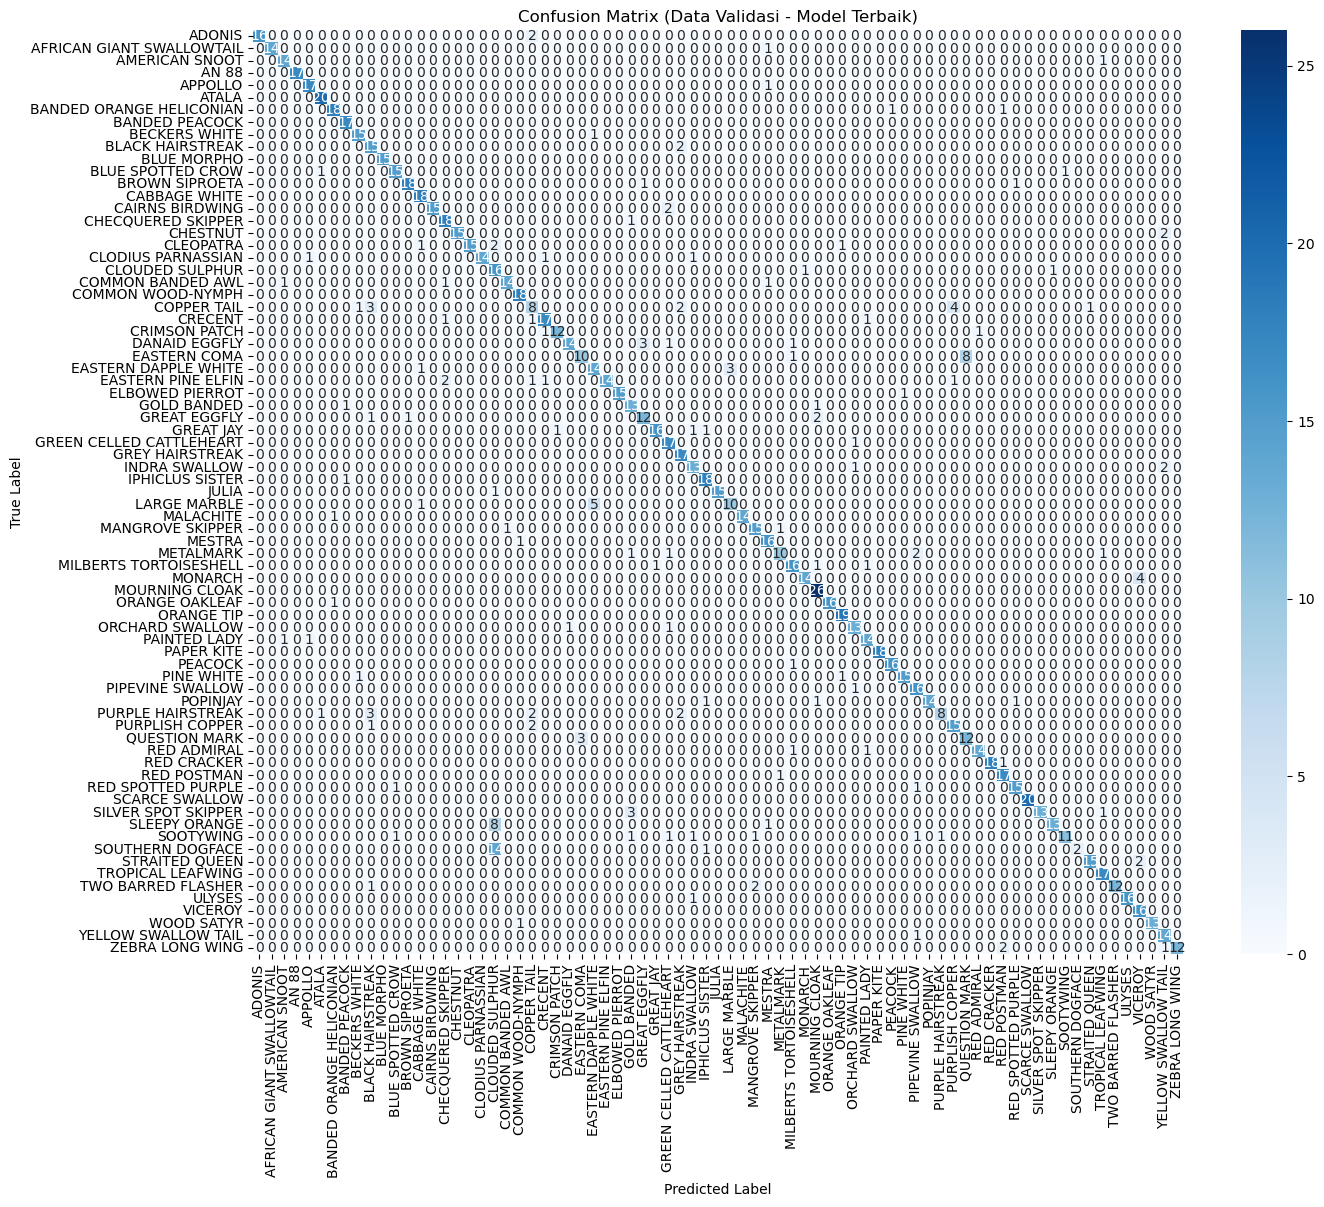

In [9]:
if best_model:
    print("\nMelakukan prediksi pada data uji (Testing_set.csv) dengan model terbaik...")

    test_generator_for_eval = valid_test_datagen.flow_from_dataframe(
        dataframe=test_df,
        directory=TEST_IMAGE_DIR,
        x_col='filename',
        y_col=None,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode=None,
        shuffle=False
    )

    predictions_on_test_set = best_model.predict(test_generator_for_eval)
    predicted_class_indices_on_test_set = np.argmax(predictions_on_test_set, axis=1)

    idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
    predicted_labels_on_test_set = [idx_to_class[idx] for idx in predicted_class_indices_on_test_set]

    submission_df = pd.DataFrame({'filename': test_df['filename'], 'predicted_label': predicted_labels_on_test_set})

    submission_output_path = os.path.join(DATA_DIR, 'submission_predictions_transfer_learning.csv')
    submission_df.to_csv(submission_output_path, index=False)
    print(f"\nHasil prediksi pada data uji disimpan ke: {submission_output_path}")
    print("Contoh hasil prediksi pada data uji:")
    print(submission_df.head())


    # --- Evaluasi mendalam pada data VALIDASI (untuk metrik per kelas) ---
    print("\nEvaluasi mendalam pada data VALIDASI (untuk metrik per kelas):")
    validation_generator_for_eval = valid_test_datagen.flow_from_dataframe(
        dataframe=val_data,
        directory=TRAIN_IMAGE_DIR,
        x_col='filename',
        y_col='label',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    val_predictions = best_model.predict(validation_generator_for_eval)
    val_predicted_classes = np.argmax(val_predictions, axis=1)
    val_true_classes = validation_generator_for_eval.classes

    true_labels_names = [idx_to_class[idx] for idx in val_true_classes]
    predicted_labels_names = [idx_to_class[idx] for idx in val_predicted_classes]


    print("\nLaporan Klasifikasi pada Data Validasi (Model Terbaik):")
    print(classification_report(true_labels_names, predicted_labels_names, target_names=CLASS_NAMES))

    cm = confusion_matrix(val_true_classes, val_predicted_classes)
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix (Data Validasi - Model Terbaik)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

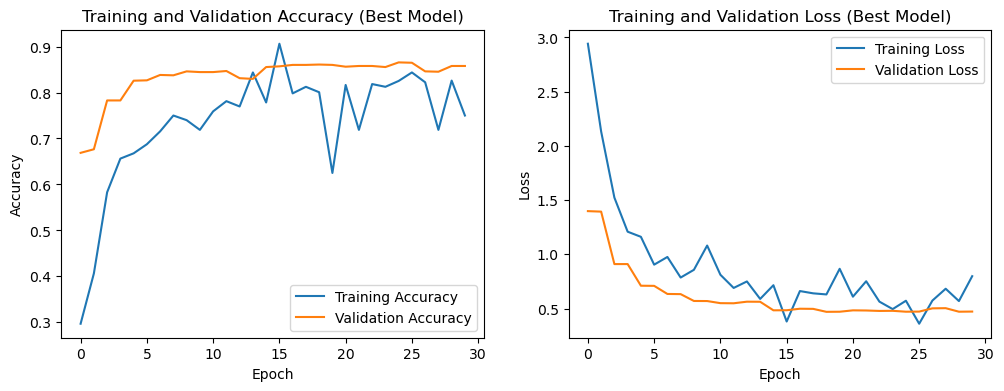

In [ ]:
if best_history:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(best_history.history['accuracy'], label='Training Accuracy')
    plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy (Best Model)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(best_history.history['loss'], label='Training Loss')
    plt.plot(best_history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss (Best Model)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

## Save Model

In [12]:
if best_model:
    model_save_path = os.path.join(DATA_DIR, 'best_butterfly_classification_model_transfer_learning.h5')
    best_model.save(model_save_path)
    print(f"\nModel terbaik (dengan Transfer Learning) berhasil disimpan sebagai '{model_save_path}'")

    print("\nMemuat kembali model yang disimpan...")
    loaded_model = tf.keras.models.load_model(model_save_path)
    print("Model berhasil dimuat.")

    print("\nMenguji konsistensi model yang dimuat dengan model asli...")
    original_predictions = best_model.predict(test_generator_for_eval)
    original_predicted_classes = np.argmax(original_predictions, axis=1)

    loaded_predictions = loaded_model.predict(test_generator_for_eval)
    loaded_predicted_classes = np.argmax(loaded_predictions, axis=1)

    if np.array_equal(original_predicted_classes, loaded_predicted_classes):
        print("Hasil prediksi dari model asli dan model yang dimuat konsisten.")
    else:
        print("PERINGATAN: Hasil prediksi dari model asli dan model yang dimuat TIDAK konsisten.")

    # Simpan hasil prediksi dari model yang dimuat ke file CSV
    predicted_labels_loaded = [idx_to_class[idx] for idx in loaded_predicted_classes]
    submission_df_loaded = pd.DataFrame({'filename': test_df['filename'], 'predicted_label': predicted_labels_loaded})
    submission_output_path_loaded = os.path.join(DATA_DIR, 'submission_predictions_loaded_model_transfer_learning.csv')
    submission_df_loaded.to_csv(submission_output_path_loaded, index=False)
    print(f"\nHasil prediksi dari model yang dimuat disimpan ke: {submission_output_path_loaded}")
    print("Contoh hasil prediksi dari model yang dimuat:")
    print(submission_df_loaded.head(10))
else:
    print("\nTidak ada model terbaik yang tersedia untuk disimpan atau dimuat.")


Model terbaik (dengan Transfer Learning) berhasil disimpan sebagai 'D:\kerjo\dibimbingbootcamp\day-31-DL\best_butterfly_classification_model_transfer_learning.h5'

Memuat kembali model yang disimpan...


Model berhasil dimuat.

Menguji konsistensi model yang dimuat dengan model asli...
88/88 ━━━━━━━━━━━━━━━━━━━━ 30s 336ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 32s 352ms/step
Hasil prediksi dari model asli dan model yang dimuat konsisten.

Hasil prediksi dari model yang dimuat disimpan ke: D:\kerjo\dibimbingbootcamp\day-31-DL\submission_predictions_loaded_model_transfer_learning.csv
Contoh hasil prediksi dari model yang dimuat:
       filename         predicted_label
0   Image_1.jpg              PINE WHITE
1   Image_2.jpg           CRIMSON PATCH
2   Image_3.jpg                  ADONIS
3   Image_4.jpg         IPHICLUS SISTER
4   Image_5.jpg  MILBERTS TORTOISESHELL
5   Image_6.jpg        SOUTHERN DOGFACE
6   Image_7.jpg              PAPER KITE
7   Image_8.jpg           INDRA SWALLOW
8   Image_9.jpg             RED CRACKER
9  Image_10.jpg         ZEBRA LONG WING
